### Prepare dataset

In [1]:
import os
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


In [2]:
# 配置参数
RANDOM_SEED = 42
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
OUTPUT_DIR = '../data'

# 设置随机种子
np.random.seed(RANDOM_SEED)

print("🚀 开始准备 EuroSAT 数据集")
print(f"📊 划分比例: Train {TRAIN_RATIO:.0%} | Val {VAL_RATIO:.0%} | Test {TEST_RATIO:.0%}")
print(f"🎲 随机种子: {RANDOM_SEED}\n")

# %% [code]
# 1. 加载数据集
print("📥 正在加载数据集...")
dataset = load_dataset("jonathan-roberts1/EuroSAT")
print(f"✅ 数据集加载完成！总样本数: {len(dataset['train'])}\n")

# 获取类别信息
class_names = dataset['train'].features['label'].names
print(f"📁 类别数量: {len(class_names)}")
print(f"📋 类别列表: {class_names}\n")

# %% [code]
# 2. 准备数据
print("🔄 准备数据...")
images = []
labels = []

for item in tqdm(dataset['train']):
    images.append(item['image'])
    labels.append(item['label'])

print(f"✅ 数据准备完成！\n")

# 统计类别分布
unique, counts = np.unique(labels, return_counts=True)
print("📊 类别分布:")
for idx, count in zip(unique, counts):
    print(f"  {class_names[idx]}: {count}")

# %% [code]
# 3. 划分数据集
print(f"\n✂️ 划分数据集（随机种子: {RANDOM_SEED}）...")

# 第一次划分：分出训练集
indices = np.arange(len(labels))
train_idx, temp_idx = train_test_split(
    indices,
    test_size=(1 - TRAIN_RATIO),
    random_state=RANDOM_SEED,
    stratify=labels
)

# 第二次划分：从剩余数据中分出验证集和测试集
temp_labels = [labels[i] for i in temp_idx]
val_test_ratio = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=(1 - val_test_ratio),
    random_state=RANDOM_SEED,
    stratify=temp_labels
)

print(f"✅ 训练集: {len(train_idx)} ({len(train_idx)/len(labels)*100:.1f}%)")
print(f"✅ 验证集: {len(val_idx)} ({len(val_idx)/len(labels)*100:.1f}%)")
print(f"✅ 测试集: {len(test_idx)} ({len(test_idx)/len(labels)*100:.1f}%)\n")


🚀 开始准备 EuroSAT 数据集
📊 划分比例: Train 70% | Val 15% | Test 15%
🎲 随机种子: 42

📥 正在加载数据集...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-26e80b6de2d4dc(…):   0%|          | 0.00/88.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27000 [00:00<?, ? examples/s]

✅ 数据集加载完成！总样本数: 27000

📁 类别数量: 10
📋 类别列表: ['annual crop', 'forest', 'herbaceous vegetation', 'highway', 'industrial', 'pasture', 'permanent crop', 'residential', 'river', 'sea or lake']

🔄 准备数据...


  0%|          | 0/27000 [00:00<?, ?it/s]

✅ 数据准备完成！

📊 类别分布:
  annual crop: 3000
  forest: 3000
  herbaceous vegetation: 3000
  highway: 2500
  industrial: 2500
  pasture: 2000
  permanent crop: 2500
  residential: 3000
  river: 2500
  sea or lake: 3000

✂️ 划分数据集（随机种子: 42）...
✅ 训练集: 18899 (70.0%)
✅ 验证集: 4050 (15.0%)
✅ 测试集: 4051 (15.0%)



💾 保存图像文件...


保存 train:   0%|          | 0/18899 [00:00<?, ?it/s]

保存 val:   0%|          | 0/4050 [00:00<?, ?it/s]

保存 test:   0%|          | 0/4051 [00:00<?, ?it/s]

✅ 所有图像保存完成！

📈 生成统计信息...

📊 数据集统计:
split                  train  val  test  total
class                                         
annual crop             2100  450   450   3000
forest                  2100  450   450   3000
herbaceous vegetation   2099  450   451   3000
highway                 1750  375   375   2500
industrial              1750  375   375   2500
pasture                 1400  300   300   2000
permanent crop          1750  375   375   2500
residential             2100  450   450   3000
river                   1750  375   375   2500
sea or lake             2100  450   450   3000

💾 统计信息已保存: ../data/dataset_statistics.csv

💾 保存划分信息...
✅ 划分信息已保存: ../data/split_info.csv
✅ 类别映射已保存: ../data/class_mapping.csv

📊 可视化数据分布...


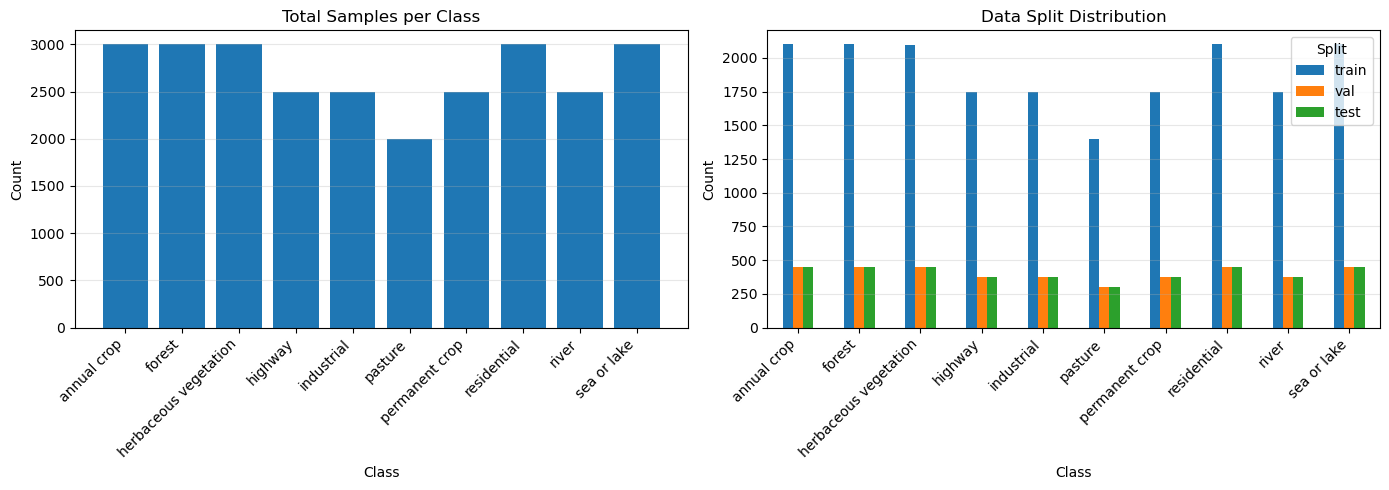

✅ 可视化完成！

🖼️ 展示样本图像...


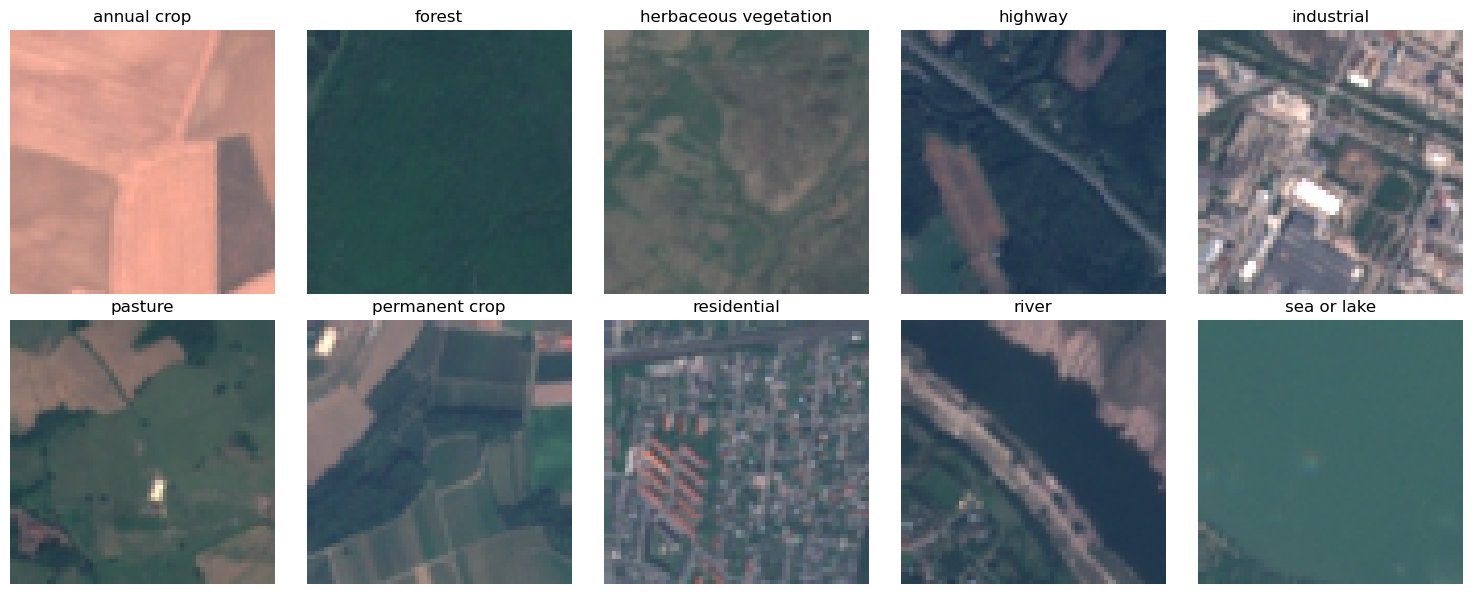

✅ 样本展示完成！


🎉 数据准备完成！

📂 输出目录: ../data
📊 训练集: 18899 张
📊 验证集: 4050 张
📊 测试集: 4051 张
🎲 随机种子: 42

✨ 可以开始训练模型了！


In [3]:
# 4. 保存图像
print("💾 保存图像文件...")

def save_split(indices, split_name):
    """保存指定划分的图像"""
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    
    # 创建类别目录
    for class_name in class_names:
        os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)
    
    # 保存图像
    for idx in tqdm(indices, desc=f"保存 {split_name}"):
        image = images[idx]
        label = labels[idx]
        class_name = class_names[label]
        
        # 文件名：类别_原始索引.jpg
        filename = f"{class_name}_{idx:05d}.jpg"
        filepath = os.path.join(split_dir, class_name, filename)
        
        # 保存
        if isinstance(image, Image.Image):
            image.save(filepath)
        else:
            Image.fromarray(np.array(image)).save(filepath)

# 保存三个数据集
save_split(train_idx, 'train')
save_split(val_idx, 'val')
save_split(test_idx, 'test')

print("✅ 所有图像保存完成！\n")

# %% [code]
# 5. 生成统计信息
print("📈 生成统计信息...")

# 创建统计表
stats = []
for split_name, split_indices in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    split_labels = [labels[i] for i in split_indices]
    for class_idx, class_name in enumerate(class_names):
        count = split_labels.count(class_idx)
        stats.append({
            'split': split_name,
            'class': class_name,
            'count': count
        })

stats_df = pd.DataFrame(stats)
pivot_table = stats_df.pivot(index='class', columns='split', values='count')
pivot_table = pivot_table[['train', 'val', 'test']]
pivot_table['total'] = pivot_table.sum(axis=1)

print("\n📊 数据集统计:")
print(pivot_table)

# 保存统计信息
stats_path = os.path.join(OUTPUT_DIR, 'dataset_statistics.csv')
pivot_table.to_csv(stats_path)
print(f"\n💾 统计信息已保存: {stats_path}")

# %% [code]
# 6. 保存划分信息（用于复现）
print("\n💾 保存划分信息...")

split_info = pd.DataFrame({
    'index': list(train_idx) + list(val_idx) + list(test_idx),
    'label': [labels[i] for i in train_idx] + 
             [labels[i] for i in val_idx] + 
             [labels[i] for i in test_idx],
    'split': ['train'] * len(train_idx) + 
             ['val'] * len(val_idx) + 
             ['test'] * len(test_idx)
})

split_info_path = os.path.join(OUTPUT_DIR, 'split_info.csv')
split_info.to_csv(split_info_path, index=False)
print(f"✅ 划分信息已保存: {split_info_path}")

# 保存类别映射
class_mapping = pd.DataFrame({
    'label_idx': range(len(class_names)),
    'class_name': class_names
})
class_mapping_path = os.path.join(OUTPUT_DIR, 'class_mapping.csv')
class_mapping.to_csv(class_mapping_path, index=False)
print(f"✅ 类别映射已保存: {class_mapping_path}")

# %% [code]
# 7. 可视化数据分布
print("\n📊 可视化数据分布...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各类别总样本数
axes[0].bar(range(len(class_names)), pivot_table['total'])
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Total Samples per Class')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# 右图：各划分的分布
pivot_table[['train', 'val', 'test']].plot(kind='bar', ax=axes[1])
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_title('Data Split Distribution')
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend(title='Split')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'data_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ 可视化完成！\n")

# %% [code]
# 8. 展示样本图像
print("🖼️ 展示样本图像...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    # 从训练集中找该类别的第一个样本
    class_indices = [idx for idx in train_idx if labels[idx] == i]
    if class_indices:
        sample_idx = class_indices[0]
        axes[i].imshow(images[sample_idx])
        axes[i].set_title(class_name)
        axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✅ 样本展示完成！\n")

# %% [markdown]
# ## ✅ 数据准备完成！
# 
# ### 📁 输出目录结构:
# ```
# ../data/
# ├── train/              # 训练集
# ├── val/                # 验证集
# ├── test/               # 测试集
# ├── dataset_statistics.csv
# ├── split_info.csv
# ├── class_mapping.csv
# ├── data_distribution.png
# └── sample_images.png
# ```
# 
# ### 🎯 下一步:
# 1. 使用训练集训练模型
# 2. 使用验证集调优超参数
# 3. 使用测试集评估最终性能

# %% [code]
print("\n" + "=" * 60)
print("🎉 数据准备完成！")
print("=" * 60)
print(f"\n📂 输出目录: {OUTPUT_DIR}")
print(f"📊 训练集: {len(train_idx)} 张")
print(f"📊 验证集: {len(val_idx)} 张")
print(f"📊 测试集: {len(test_idx)} 张")
print(f"🎲 随机种子: {RANDOM_SEED}")
print(f"\n✨ 可以开始训练模型了！")